### Lesson 3: Building makemore Part 2: MLP

[Youtube video lecture](https://www.youtube.com/watch?v=TCH_1BHY58I)  
[makemore repo](https://github.com/karpathy/makemore)  
[Juputer notebook files](https://github.com/karpathy/nn-zero-to-hero/blob/master/lectures/makemore/makemore_part2_mlp.ipynb)

Video upload date: Sep 12, 2022 (length: 1 hr 15 min)  
Watched on: Nov 25, 2025  
Reproduced on: Nov 26, 2025  

Content:
- Implement a multilayer perceptron (MLP) character-level language model
- Machine learning basics: train/dev/test split, learning rate
- [torch] tensor indexing, view(), F.cross_entropy

**What is different with Bigram character LM with neural network from Lesson 2?**   
Here each character is represented as a learnable, high dimensional embedding (30 for this implementation).
In Lesson 2, each character is represented with fixed one-hot encoding.

In [3]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt

In [2]:
words = open('data/names.txt', 'r').read().splitlines()
print(len(words))
words[:10]

32033


['emma',
 'olivia',
 'ava',
 'isabella',
 'sophia',
 'charlotte',
 'mia',
 'amelia',
 'harper',
 'evelyn']

In [4]:
# build the vacabulary of characters and mappings to/from integers
chars = sorted(list(set(''.join(words))))
stoi = {s:i+1 for i,s in enumerate(chars)}
stoi['.'] = 0
itos = {i:s for s,i in stoi.items()}
print(itos)

{1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22: 'v', 23: 'w', 24: 'x', 25: 'y', 26: 'z', 0: '.'}


In [ ]:
# build the dataset

block_size = 3  # context length: how many characters do we take to predict the next one?
X, Y = [], []

for w in words[:3]:  # use only first three words
    print(w)
    context = [0] * block_size
    for ch in w + '.':
        idx = stoi[ch]
        X.append(context)
        Y.append(idx)
        print(''.join(itos[i] for i in context), '--->', itos[idx])
        context = context[1:] + [idx]  # crop and append

X = torch.tensor(X)
Y = torch.tensor(Y)

emma
... ---> e
..e ---> m
.em ---> m
emm ---> a
mma ---> .
olivia
... ---> o
..o ---> l
.ol ---> i
oli ---> v
liv ---> i
ivi ---> a
via ---> .
ava
... ---> a
..a ---> v
.av ---> a
ava ---> .


In [13]:
X.shape, X.dtype, Y.shape, Y.dtype

(torch.Size([16, 3]), torch.int64, torch.Size([16]), torch.int64)

In [14]:
# build the dataset with train/dev/test split
block_dize = 3

def build_dataset(words):
    X, Y = [], []

    for w in words:  # use given 'words'
        # print(w)
        context = [0] * block_size
        for ch in w + '.':
            idx = stoi[ch]
            X.append(context)
            Y.append(idx)
            # print(''.join(itos[i] for i in context), '--->', itos[idx])
            context = context[1:] + [idx]  # crop and append

    X = torch.tensor(X)
    Y = torch.tensor(Y)
    print(X.shape, Y.shape)
    return X, Y

import random
random.seed(42)
random.shuffle(words)
n1 = int(0.8*len(words))
n2 = int(0.9*len(words))

Xtr, Ytr = build_dataset(words[:n1])
Xdev, Ydev = build_dataset(words[n1:n2])
Xte, Yte = build_dataset(words[n2:])

torch.Size([182625, 3]) torch.Size([182625])
torch.Size([22655, 3]) torch.Size([22655])
torch.Size([22866, 3]) torch.Size([22866])


In [15]:
C = torch.randn((27, 2))  # character embedding, convert each character into a 2-dim embedding

In [16]:
emb = C[X]
emb.shape

torch.Size([16, 3, 2])

In [ ]:
# first layer MLP
W1 = torch.randn((6, 100))
b1 = torch.randn(100)

In [18]:
h = torch.tanh(emb.view(-1, 6) @ W1 + b1)

In [21]:
# second layer MLP
W2 = torch.randn((100, 27))
b2 = torch.randn(27)

In [22]:
logits = h @ W2 + b2

In [23]:
logits.shape

torch.Size([16, 27])

In [24]:
counts = logits.exp()
prob = counts / counts.sum(1, keepdims=True)
prob.shape

torch.Size([16, 27])

In [30]:
loss = -prob[torch.arange(16), Y].log().mean()
loss

tensor(16.6130)

In [ ]:
# put into one piece

In [31]:
Xtr.shape, Ytr.shape

(torch.Size([182625, 3]), torch.Size([182625]))

In [35]:
g = torch.Generator().manual_seed(123)
C = torch.randn((27, 10), generator=g)  # 10-dim character embedding
W1 = torch.randn((30, 200), generator=g)  # 3 character concatenated --> 3*10=30 dim as MLP input
b1 = torch.randn(200, generator=g)
W2 = torch.randn((200, 27), generator=g)
b2 = torch.randn(27, generator=g)
parameters = [C, W1, b1, W2, b2]

In [36]:
sum(p.nelement() for p in parameters)  # number of paramaters in total

11897

In [37]:
for p in parameters:
    p.requires_grad = True

In [38]:
lre = torch.linspace(-3, 0, 1000)
lrs = 10**lre

In [39]:
lri = []
lossi = []
stepi = []

In [47]:
for i in range(200000):

    # minibatch construct
    ix = torch.randint(0, Xtr.shape[0], (32, ))  # batch size = 32

    # forward pass
    emb = C[Xtr[ix]]  # (32, 3, 10)
    h  =torch.tanh(emb.view(-1, 30) @ W1 + b1)  # (32, 200)
    logits = h @ W2 + b2  # (32, 27)
    loss = F.cross_entropy(logits, Ytr[ix])
    # print(loss.item())

    # backward pass
    for p in parameters:
        p.grad = None
    loss.backward()

    # update
    # lr = lrs[i]
    lr = 0.1 if i < 100000 else 0.01
    for p in parameters:
        p.data += -lr * p.grad
    
    # track stats
    # lri.append(lre[i])
    stepi.append(i)
    lossi.append(loss.log10().item())

print(loss.item())

2.388187885284424


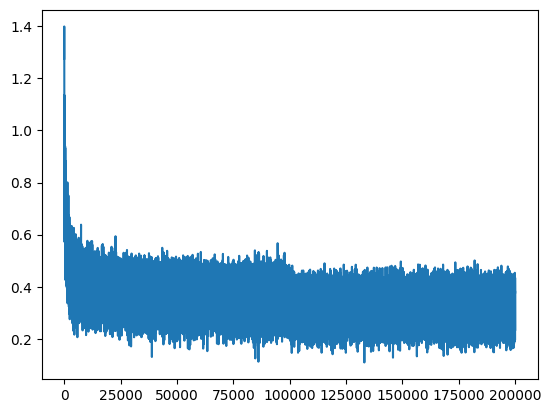

In [49]:
plt.plot(stepi, lossi)

In [50]:
loss

tensor(2.3882, grad_fn=<NllLossBackward0>)

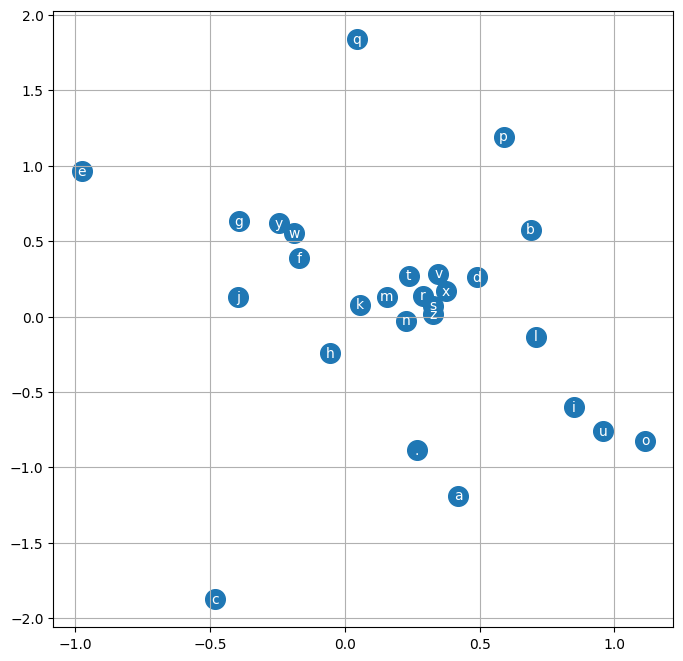

In [ ]:
# visualize dimensions 0 and 1 of the embedding matrix C for all characters
plt.figure(figsize=(8, 8))
plt.scatter(C[:,0].data, C[:, 1].data, s=200)
for i in range(C.shape[0]):
    plt.text(C[i,0].item(), C[i,1].item(), itos[i], ha='center', va='center', color='white')
plt.grid('minor')